Epoch: 1 | Training Loss: 0.19067620720410267 | Validation Loss: 0.08535704082551698
Epoch: 5 | Training Loss: 0.06333147997549228 | Validation Loss: 0.06375788277107046
Epoch: 10 | Training Loss: 0.05770843540822146 | Validation Loss: 0.06014131984740804
Epoch: 15 | Training Loss: 0.055226858580861904 | Validation Loss: 0.056609346367735264
Epoch: 20 | Training Loss: 0.053839798296407025 | Validation Loss: 0.05763905570680868
Epoch: 25 | Training Loss: 0.05041682778428997 | Validation Loss: 0.0550469844575317
Epoch: 30 | Training Loss: 0.049334182440941836 | Validation Loss: 0.05448859121680397
Epoch: 35 | Training Loss: 0.048706694059759234 | Validation Loss: 0.05448997213187639
Epoch: 40 | Training Loss: 0.04858429667861425 | Validation Loss: 0.05422437458751396


Best validation loss: 0.05422437458751396
Best model weights saved: lstm_weights.pkl


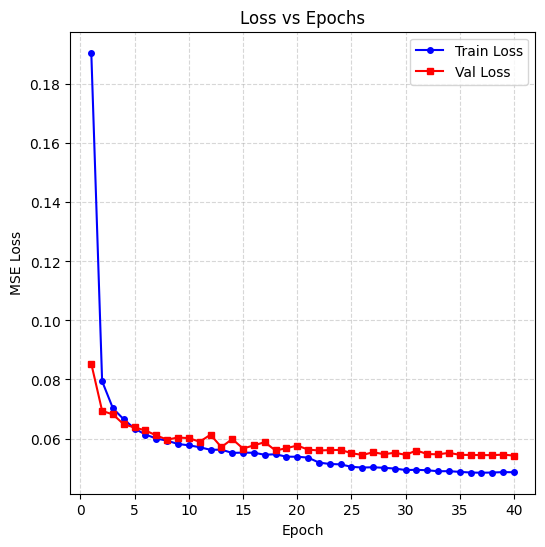

Plot saved successfully: training_curve_lstm.png
LSTM | MSE: 3.8414  MAE: 1.4524  Huber: 1.0381
Validation Loss: 0.05422437458751396


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

LR= 1e-3 # Adam learning rate
WEIGHT_DECAY  = 5e-4  # L2 regularisation coefficient
input_steps= 72
output_steps=12
input_size=14
hidden_size=64 #less hidden size for lesser dataset size
target_index= 1
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

data=pd.read_csv('/content/jena_climate_dataset.csv')
data = data.drop(columns=["Date Time"])
data = data.reset_index(drop=True)          # ensure index starts at 0
data= data.groupby(data.index//6).mean()
data = data.astype(np.float32)
data=data.to_numpy()
data=np.array(data)

#normalisation
mean= data.mean(axis=0)
std= data.std(axis=0)
std[std==0]=1
data= (data-mean)/std

train_data= data[:int(len(data)*0.8)]
val_data= data[int(len(data)*0.8):]

class JenaClimateForecastDataset(Dataset):
    def __init__(self, data, input_steps, output_steps, target_index=1):
        """
        data: Numpy array of shape (num_samples, num_features)
        target_index: Column index of the feature you want to predict (e.g., Temperature)
        """
        self.data = torch.tensor(data, dtype=torch.float32)
        self.input_steps = input_steps
        self.output_steps = output_steps
        self.target_index = target_index

    def __len__(self):
        return len(self.data) -self.input_steps - self.output_steps + 1

    def __getitem__(self, i):
        # Past 72 hours (all features)
        x = self.data[i : i + self.input_steps]

        # Future 12 hours (only target feature, e.g., temperature)
        y = self.data[i + self.input_steps : i + self.input_steps + self.output_steps, self.target_index]

        return x, y

train_dataset= JenaClimateForecastDataset(train_data, input_steps, output_steps, target_index)
val_dataset= JenaClimateForecastDataset(val_data, input_steps, output_steps, target_index)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=256, shuffle=False)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

class TempPrediction(nn.Module):
    def __init__(self, input_size, hidden_size, output_steps):
        super().__init__()
        self.hidden_size = hidden_size
        self.output_steps = output_steps
        self.dropout= nn.Dropout(0.3)

        limit1= np.sqrt(6 /(input_size + hidden_size))
        limit2= np.sqrt(6/(2*hidden_size))

        self.W1 = nn.Parameter(torch.FloatTensor(4*hidden_size, input_size+hidden_size).uniform_(-limit1, limit1))
        self.W2 = nn.Parameter(torch.FloatTensor(4*hidden_size, 2*hidden_size).uniform_(-limit2, limit2))
        self.b1= nn.Parameter(torch.cat([
            torch.ones(hidden_size, 1),
            torch.zeros(hidden_size, 1),
            torch.zeros(hidden_size, 1),
            torch.zeros(hidden_size, 1)
        ]))

        self.b2 = nn.Parameter(torch.cat([
            torch.ones(hidden_size, 1),
            torch.zeros(hidden_size, 1),
            torch.zeros(hidden_size, 1),
            torch.zeros(hidden_size, 1)
        ]))

        # output projection
        self.out = nn.Linear(hidden_size, output_steps)

    def forward(self, x):
        batch_size = x.size(0)
        h1 = torch.zeros(batch_size, self.hidden_size, 1).to(x.device)
        c1 = torch.zeros(batch_size, self.hidden_size, 1).to(x.device)
        h2= torch.zeros(batch_size, self.hidden_size, 1).to(x.device)
        c2 = torch.zeros(batch_size, self.hidden_size, 1).to(x.device)

        for t in range(x.size(1)):
            x_t1 = x[:, t, :].unsqueeze(2)
            xh1= torch.cat([x_t1, h1], dim=1)

            gates1 = self.W1 @ xh1 + self.b1
            f_t1, i_t1, cand1, o_t1 = gates1.chunk(4, dim=1)
            f_t1= torch.sigmoid(f_t1)
            i_t1= torch.sigmoid(i_t1)
            cand1 = torch.tanh(cand1)
            o_t1= torch.sigmoid(o_t1)

            c1= f_t1*c1 + i_t1 * cand1
            h1 =o_t1*torch.tanh(c1)
            h1= self.dropout(h1)

            xh2= torch.cat([h1, h2], dim=1)

            gates2 = self.W2 @xh2 + self.b2
            f_t2, i_t2, cand2, o_t2 = gates2.chunk(4, dim=1)
            f_t2= torch.sigmoid(f_t2)
            i_t2= torch.sigmoid(i_t2)
            cand2 = torch.tanh(cand2)
            o_t2= torch.sigmoid(o_t2)

            c2= f_t2* c2 + i_t2 * cand2
            h2 =o_t2*torch.tanh(c2)


        return self.out(h2.squeeze(2))             # (batch, output_steps)

def train(model, loader, criterion, optimizer, device):
    model.train()
    total_loss,total = 0.0, 0

    for input_batch, output_batch in loader:
        input_batch, output_batch = input_batch.to(device), output_batch.to(device)

        optimizer.zero_grad()
        preds = model.forward(input_batch)
        loss = criterion(preds, output_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()*input_batch.size(0)
        total+= input_batch.size(0)

    return total_loss / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total = 0.0, 0

    for input_batch, output_batch in loader:
        input_batch, output_batch = input_batch.to(device), output_batch.to(device)

        preds = model.forward(input_batch)
        loss = criterion(preds, output_batch)

        total_loss += loss.item()*input_batch.size(0)
        total+= input_batch.size(0)

    return total_loss / total


model = TempPrediction(input_size, hidden_size, output_steps).to(DEVICE)
criterion = nn.MSELoss()

optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

history = {
    "train_loss": [], "val_loss": []
}

best_val_loss= float("inf")

for epoch in range(1, 41):
    train_loss=train(model, train_loader, criterion, optimizer, DEVICE)
    val_loss=evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    if epoch%5==0 or epoch==1:
        print(f"Epoch: {epoch} | Training Loss: {train_loss} | Validation Loss: {val_loss}")

    # Track best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {}
        for k, v in model.state_dict().items():
            best_state[k] = v.cpu().clone()
print("\n")
print(f"Best validation loss: {best_val_loss}")

#Save model weights
weights_path = "lstm_weights.pkl"
with open(weights_path, "wb") as f:
    pickle.dump(best_state, f)
print(f"Best model weights saved: {weights_path}")

model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})

#Training curves
epochs_range = range(1, 41)

plt.figure(figsize=(6, 6))
plt.plot(epochs_range, history["train_loss"], "b-o", markersize=4, label="Train Loss")
plt.plot(epochs_range, history["val_loss"],   "r-s", markersize=4, label="Val Loss")
plt.title("Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.savefig("training_curve_lstm.png")
plt.show()
print("Plot saved successfully: training_curve_lstm.png")

#Scatter plot
model.eval()
all_preds, all_targets= [], []

with torch.no_grad():
    for input_batch, output_batch in val_loader:
        input_batch= input_batch.to(DEVICE)
        preds = model.forward(input_batch)
        all_preds.append(preds.cpu().numpy())
        all_targets.append(output_batch.cpu().numpy())

# stack all batches together
all_preds = np.concatenate(all_preds, axis=0)
all_targets = np.concatenate(all_targets, axis=0)

temp_mean= mean[target_index]
temp_std= std[target_index]
all_preds= all_preds*temp_std+temp_mean
all_targets= all_targets*temp_std+temp_mean


flat_preds= all_preds.flatten()
flat_targets = all_targets.flatten()

def mae_loss(pred, true):
    return np.mean(np.abs(pred - true))

def huber_loss(pred, true, delta=1.0):
    err = pred - true
    abs_err = np.abs(err)
    quad = 0.5 * err**2
    lin = delta * (abs_err - 0.5 * delta)
    return np.mean(np.where(abs_err <= delta, quad, lin))

mse_val = np.mean((all_preds - all_targets) ** 2)
mae_val = mae_loss(all_preds, all_targets)
huber_val = huber_loss(all_preds, all_targets)

print(f"LSTM | MSE: {mse_val:.4f}  MAE: {mae_val:.4f}  Huber: {huber_val:.4f}")

# save for compare.py
np.savez("lstm_eval.npz", preds=all_preds, targets=all_targets)

#Final evaluation on validation set
val_loss= evaluate(model, val_loader, criterion, DEVICE)
print(f"Validation Loss: {val_loss}")

Epoch: 1 | Training Loss: 0.5094500324815102 | Validation Loss: 0.20367241429269792
Epoch: 5 | Training Loss: 0.11441733775090523 | Validation Loss: 0.09637744615258634
Epoch: 10 | Training Loss: 0.09103861412319206 | Validation Loss: 0.10133085546995824
Epoch: 15 | Training Loss: 0.08667565342660971 | Validation Loss: 0.07934819420224352
Epoch: 20 | Training Loss: 0.08422354081684531 | Validation Loss: 0.07578796161986656
Epoch: 25 | Training Loss: 0.08264984089623692 | Validation Loss: 0.07470218700396344
Epoch: 30 | Training Loss: 0.0819264324454138 | Validation Loss: 0.07412059280922985
Epoch: 35 | Training Loss: 0.08101899253697156 | Validation Loss: 0.0774399872214868
Epoch: 40 | Training Loss: 0.08020079164584634 | Validation Loss: 0.07449170347435739


Best validation loss: 0.0736112449869907
Best model weights saved: transformer_weights.pkl


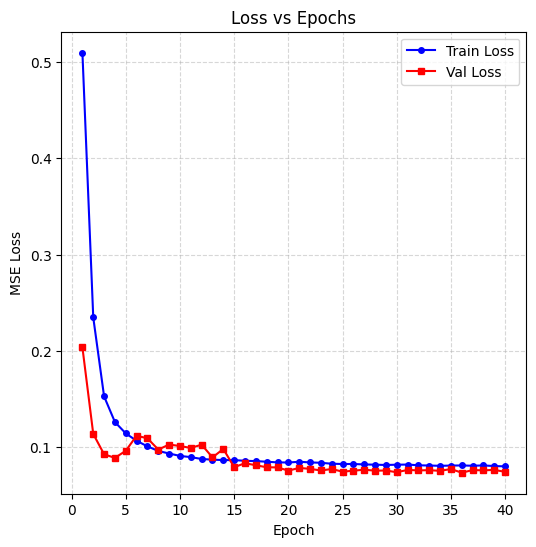

Plot saved successfully: training_curve_transformer.png
Transformer | MSE: 5.2148  MAE: 1.6346  Huber: 1.2095
Validation Loss: 0.0736112449869907


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

LR= 5e-4 # Adam learning rate
WEIGHT_DECAY  = 5e-4  # L2 regularisation coefficient
input_steps= 72
output_steps=12
heads= 4
num_layers=3
input_size=14
d_model= 64 #reasonable hidden size for the input steps
forward_exp= d_model*4
target_index= 1
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

data=pd.read_csv('/content/jena_climate_dataset.csv')
data = data.drop(columns=["Date Time"])
data = data.reset_index(drop=True)          # ensure index starts at 0
data= data.groupby(data.index//6).mean()
data = data.astype(np.float32)
data=data.to_numpy()
data=np.array(data)

#normalisation
mean= data.mean(axis=0)
std= data.std(axis=0)
std[std==0]=1
data= (data-mean)/std

train_data= data[:int(len(data)*0.8)]
val_data= data[int(len(data)*0.8):]

class JenaClimateForecastDataset(Dataset):
    def __init__(self, data, input_steps, output_steps, target_index=1):
        """
        data: Numpy array of shape (num_samples, num_features)
        target_index: Column index of the feature you want to predict (e.g., Temperature)
        """
        self.data = torch.tensor(data, dtype=torch.float32)
        self.input_steps = input_steps
        self.output_steps = output_steps
        self.target_index = target_index

    def __len__(self):
        return len(self.data) -self.input_steps - self.output_steps + 1

    def __getitem__(self, i):
        # Past 72 hours (all features)
        x = self.data[i : i + self.input_steps]

        # Future 12 hours (only target feature, e.g., temperature)
        y = self.data[i + self.input_steps : i + self.input_steps + self.output_steps, self.target_index]

        return x, y

train_dataset= JenaClimateForecastDataset(train_data, input_steps, output_steps, target_index)
val_dataset= JenaClimateForecastDataset(val_data, input_steps, output_steps, target_index)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=256, shuffle=False)


class LayerNorm(nn.Module):
    def __init__(self, d_model, eps=1e-6):
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(d_model))
        self.beta = nn.Parameter(torch.zeros(d_model))
        self.eps = eps

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        std= x.std(dim=-1, keepdim=True)
        return self.gamma * (x - mean) / (std + self.eps) + self.beta #applying a learnt scale and shift that will actually be more useful on a per-feature basis than mean 0 and std 1- applyed across hidden_size for every timestep of every batch

class Attention(nn.Module):
    def __init__(self, d_model, heads):
        super(Attention, self).__init__()
        self.d_model = d_model
        self.heads = heads
        if(self.d_model%self.heads==0):
            self.d_k = self.d_model//self.heads
        else:
            print("d_model must be divisible by heads")

        self.values= nn.Linear(self.d_model, self.d_model, bias=False)
        self.keys= nn.Linear(self.d_model, self.d_model, bias=False)
        self.queries= nn.Linear(self.d_model, self.d_model, bias=False)
        self.out= nn.Linear(heads*self.d_k, d_model)

    def forward(self, q, k, v, mask):
        n=q.shape[0]
        v=self.values(v)
        k=self.keys(k)
        q=self.queries(q)
        key_len, query_len, val_len = k.shape[1], q.shape[1], v.shape[1]

        v=v.reshape(n, val_len, self.heads, self.d_k)
        q=q.reshape(n, query_len, self.heads, self.d_k)
        k=k.reshape(n, key_len, self.heads, self.d_k)
        attention= torch.einsum("nqhd, nkhd->nhqk", [q, k])

        if mask is not None:
            attention= attention.masked_fill(mask==0, float("-1e20"))

        att_fin = torch.softmax(attention/(self.d_k**0.5), dim=3)

        out = torch.einsum("nhqk, nkhd->nqhd", [att_fin, v]).reshape(n, query_len, self.heads*self.d_k)
        out_fin= self.out(out)
        return out_fin


class Encoder(nn.Module):
    def __init__(self, heads, d_model, forward_exp):
        super(Encoder, self).__init__()
        self.attention= Attention(d_model, heads)
        self.feedforward= nn.Sequential(
            nn.Linear(d_model, forward_exp),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(forward_exp, d_model)
        )
        self.dropout= nn.Dropout(0.2)
        self.layernorm1= LayerNorm(d_model, eps=1e-6)
        self.layernorm2= LayerNorm(d_model, eps=1e-6)

    def forward(self, q,k,v,mask):
        attention= self.attention.forward(q, k, v, mask)
        x1= self.layernorm1.forward(q+attention)
        x2=self.dropout(x1)
        f= self.feedforward(x2)
        x= f+x2
        x3= self.layernorm2.forward(x)
        x4= self.dropout(x3)
        return x4

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=input_steps):
        super(PositionalEncoding, self).__init__()
        pe= torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float() #(max_len, 1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.pe = pe.unsqueeze(0)   # (1, max_len, d_model)

    def forward(self, x):
        return x +self.pe[:, :x.size(1), :].to(x.device)


class Transformer(nn.Module):
    def __init__(self, input_size, d_model, heads, num_layers, output_steps):
        super(Transformer, self).__init__()
        self.input= nn.Linear(input_size, d_model)
        self.pe= PositionalEncoding(d_model)
        self.dropout= nn.Dropout(0.1)
        self.layers= nn.ModuleList([
            Encoder(heads, d_model, forward_exp)
            for _ in range(num_layers)
        ])
        self.out= nn.Linear(d_model, output_steps)

    def forward(self, x):
        x = self.input(x)
        x = self.pe(x)
        x = self.dropout(x)
        for layer in self.layers:
            x = layer.forward(x, x, x, None)
        x = x[:, -1, :]            # take last timestep (batch, d_model)
        return self.out(x)         # (batch, 12)

def train(model, loader, criterion, optimizer, device):
    model.train()
    total_loss,total = 0.0, 0

    for input_batch, output_batch in loader:
        input_batch, output_batch = input_batch.to(device), output_batch.to(device)

        optimizer.zero_grad()
        preds = model.forward(input_batch)
        loss = criterion(preds, output_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()*input_batch.size(0)
        total+= input_batch.size(0)

    return total_loss / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total = 0.0, 0

    for input_batch, output_batch in loader:
        input_batch, output_batch = input_batch.to(device), output_batch.to(device)

        preds = model.forward(input_batch)
        loss = criterion(preds, output_batch)

        total_loss += loss.item()*input_batch.size(0)
        total+= input_batch.size(0)

    return total_loss / total


model = Transformer(input_size, d_model, heads, num_layers, output_steps).to(DEVICE)
criterion = nn.MSELoss()

warmup_epochs= 5
target_lr=5e-4

optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

def set_lr(optimizer, lr):
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr

history = {
    "train_loss": [], "val_loss": []
}

best_val_loss= float("inf")

for epoch in range(1, 41):
    if epoch <= warmup_epochs:
        warmup_lr = target_lr* (epoch/ warmup_epochs)
        set_lr(optimizer, warmup_lr)

    train_loss=train(model, train_loader, criterion, optimizer, DEVICE)
    val_loss=evaluate(model, val_loader, criterion, DEVICE)
    if epoch > warmup_epochs:
        scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    if epoch%5==0 or epoch==1:
        print(f"Epoch: {epoch} | Training Loss: {train_loss} | Validation Loss: {val_loss}")

    # Track best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {}
        for k, v in model.state_dict().items():
            best_state[k] = v.cpu().clone()
print("\n")
print(f"Best validation loss: {best_val_loss}")

#Save model weights
weights_path = "transformer_weights.pkl"
with open(weights_path, "wb") as f:
    pickle.dump(best_state, f)
print(f"Best model weights saved: {weights_path}")

model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})

#Training curves
epochs_range = range(1, 41)

plt.figure(figsize=(6, 6))
plt.plot(epochs_range, history["train_loss"], "b-o", markersize=4, label="Train Loss")
plt.plot(epochs_range, history["val_loss"],   "r-s", markersize=4, label="Val Loss")
plt.title("Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.savefig("training_curve_transformer.png")
plt.show()
print("Plot saved successfully: training_curve_transformer.png")

#Scatter plot
model.eval()
all_preds, all_targets= [], []

with torch.no_grad():
    for input_batch, output_batch in val_loader:
        input_batch= input_batch.to(DEVICE)
        preds = model.forward(input_batch)
        all_preds.append(preds.cpu().numpy())
        all_targets.append(output_batch.cpu().numpy())

# stack all batches together
all_preds = np.concatenate(all_preds, axis=0)
all_targets = np.concatenate(all_targets, axis=0)

temp_mean= mean[target_index]
temp_std= std[target_index]
all_preds= all_preds*temp_std+temp_mean #denormalise back to celsius
all_targets= all_targets*temp_std+temp_mean

def mae_loss(pred, true):
    return np.mean(np.abs(pred - true))

def huber_loss(pred, true, delta=1.0):
    err = pred - true
    abs_err = np.abs(err)
    quad = 0.5 * err**2
    lin = delta * (abs_err - 0.5 * delta)
    return np.mean(np.where(abs_err <= delta, quad, lin))

mse_val = np.mean((all_preds - all_targets) ** 2)
mae_val = mae_loss(all_preds, all_targets)
huber_val = huber_loss(all_preds, all_targets)

print(f"Transformer | MSE: {mse_val:.4f}  MAE: {mae_val:.4f}  Huber: {huber_val:.4f}")

# save for compare.py
np.savez("transformer_eval.npz", preds=all_preds, targets=all_targets)

#Final evaluation on validation set
val_loss= evaluate(model, val_loader, criterion, DEVICE)
print(f"Validation Loss: {val_loss}")